In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, rand_score

from pytspl.simplicial_complex import SCBuilder
from pytspl.cell_complex import CellComplex
from pytspl.embeddings.k_simplex2vec import cell2vec

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["figure.dpi"] = 120


In [2]:
n = 40  
p = 0.9
q = 0.1
probs = [[p, q, q],
         [q, p, q],
         [q, q, p]]

G = nx.stochastic_block_model([n, n, n], probs, seed=42)

print("SBM Graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

nodes = list(G.nodes())
edges = list(G.edges())

sc_builder = SCBuilder(
    nodes=nodes,
    edges=edges,
    node_features={},
    edge_features={},
)

# clique complex up to triangles
sc = sc_builder.to_simplicial_complex(condition="all")

print("\nSimplicialComplex from SCBuilder:")
print("Nodes:", len(sc.nodes))
print("Edges:", len(sc.edges))
print("Triangles:", len(sc.triangles))


SBM Graph:
Nodes: 120
Edges: 2632

SimplicialComplex from SCBuilder:
Nodes: 120
Edges: 2632
Triangles: 23932


Node embedding shape: (120, 32)


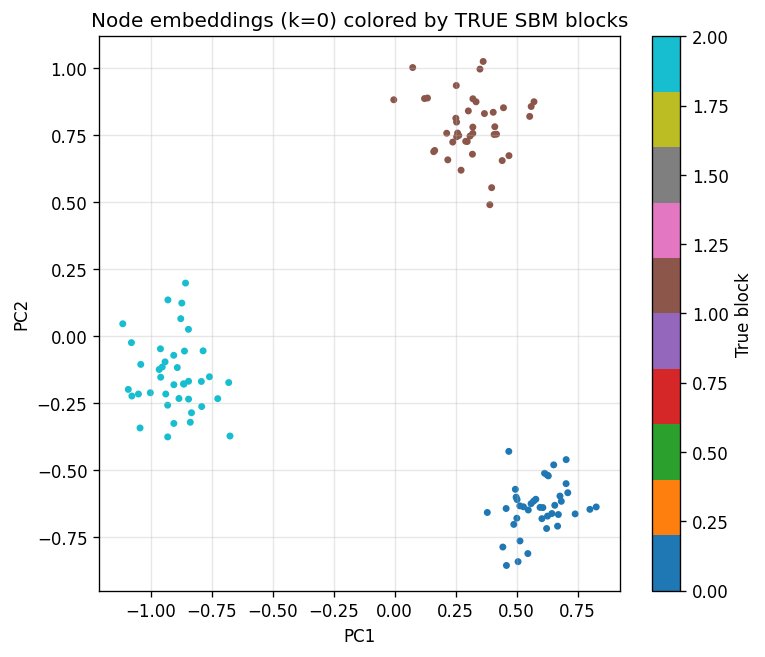

Node test: ARI = 1.000, RI = 1.000


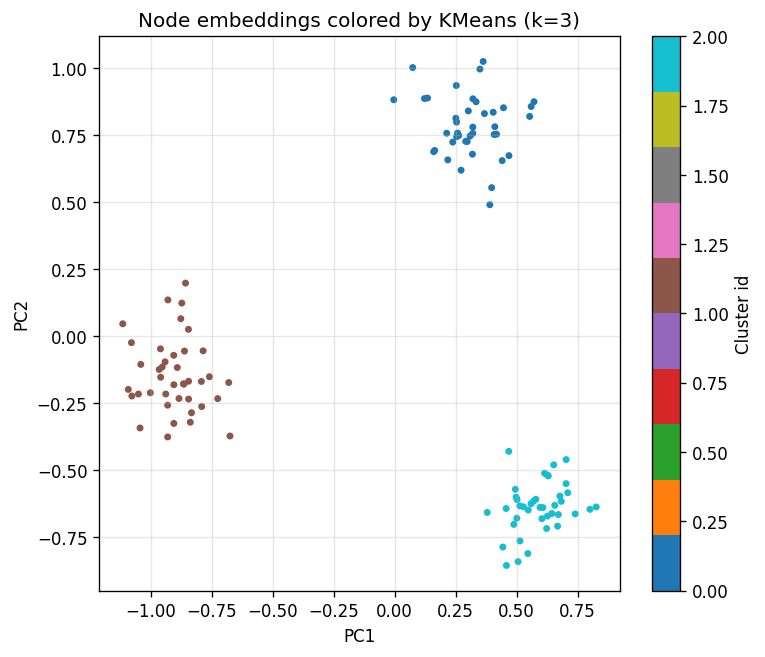

In [3]:
emb_dim = 32
walk_length = 20
number_walks = 40

node_emb = cell2vec(
    cc=sc,
    k=0,
    emb_dim=emb_dim,
    walk_length=walk_length,
    number_walks=number_walks,
    scheme="uniform",
    laziness=None,
    seed=123,
)

print("Node embedding shape:", node_emb.shape)

# TRUE labels from SBM partition
partitions = G.graph["partition"]   # 3 lists of node IDs
node_to_block = {}
for b, part in enumerate(partitions):
    for u in part:
        node_to_block[u] = b

y_nodes_true = np.array([node_to_block[u] for u in sc.nodes])

# PCA visualization
pca_nodes = PCA(n_components=2, random_state=0)
node_2d = pca_nodes.fit_transform(node_emb)

plt.scatter(node_2d[:, 0], node_2d[:, 1], c=y_nodes_true, s=10, cmap="tab10")
plt.title("Node embeddings (k=0) colored by TRUE SBM blocks")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="True block")
plt.show()

# KMeans
kmeans_nodes = KMeans(n_clusters=3, random_state=0)
node_labels_pred = kmeans_nodes.fit_predict(node_emb)

node_ari = adjusted_rand_score(y_nodes_true, node_labels_pred)
node_ri = rand_score(y_nodes_true, node_labels_pred)

print(f"Node test: ARI = {node_ari:.3f}, RI = {node_ri:.3f}")

plt.scatter(node_2d[:, 0], node_2d[:, 1], c=node_labels_pred, s=10, cmap="tab10")
plt.title("Node embeddings colored by KMeans (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="Cluster id")
plt.show()


In [4]:
emb_dim_edges = 32
walk_length_edges = 20
number_walks_edges = 40

edge_emb = cell2vec(
    cc=sc,
    k=1,
    emb_dim=emb_dim_edges,
    walk_length=walk_length_edges,
    number_walks=number_walks_edges,
    scheme="uniform",
    laziness=None,
    seed=3,
)

print("Edge embedding shape:", edge_emb.shape)


Edge embedding shape: (2632, 32)


Unique edge types (block pairs): [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2), (2, 2)]
Number of edge types: 6
Counts per edge type: Counter({(1, 1): 709, (2, 2): 709, (0, 0): 700, (0, 1): 194, (1, 2): 167, (0, 2): 153})


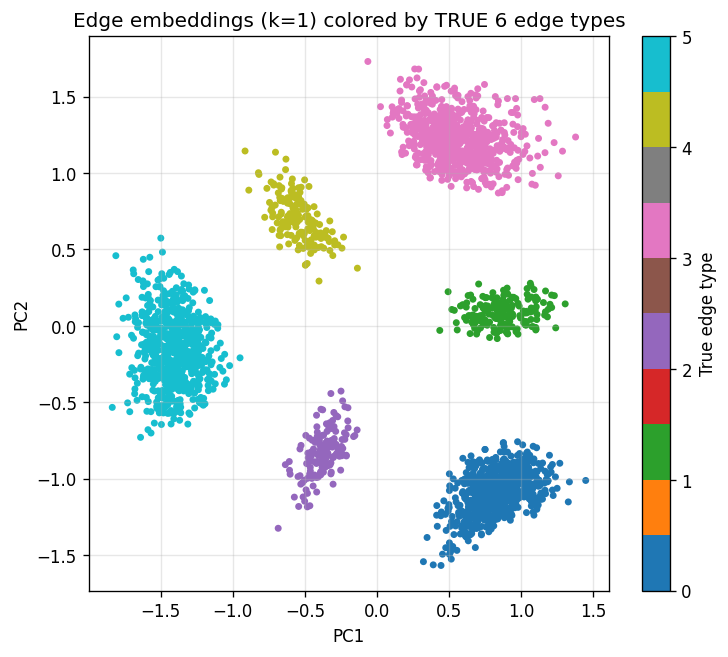

Edge test: ARI = 0.556, RI = 0.856


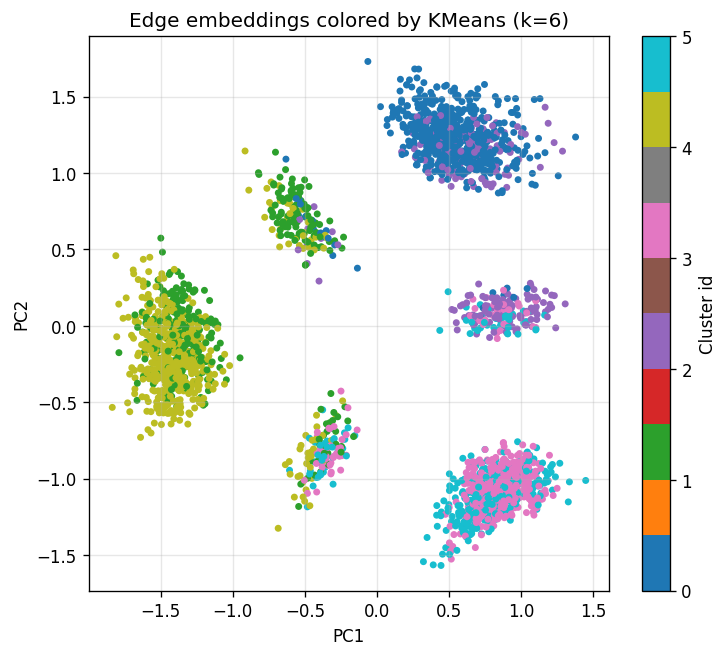

In [ ]:
edge_types = []
for (u, v) in sc.edges:
    a = node_to_block[u]
    b = node_to_block[v]
    edge_types.append(tuple(sorted((a, b))))

edge_unique_types = sorted(set(edge_types))
print("Unique edge types (block pairs):", edge_unique_types)
print("Number of edge types:", len(edge_unique_types))
print("Counts per edge type:", Counter(edge_types))

edge_type_to_id = {t: i for i, t in enumerate(edge_unique_types)}
y_edges_true = np.array([edge_type_to_id[t] for t in edge_types])

# PCA for visualization
pca_edges = PCA(n_components=2, random_state=0)
edge_2d = pca_edges.fit_transform(edge_emb)

plt.scatter(edge_2d[:, 0], edge_2d[:, 1], c=y_edges_true, s=10, cmap="tab10")
plt.title("Edge embeddings (k=1) colored by TRUE 6 edge types")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="True edge type")
plt.show()

# KMeans with k=6
kmeans_edges = KMeans(n_clusters=len(edge_unique_types), random_state=0)
edge_labels_pred = kmeans_edges.fit_predict(edge_emb)

edge_ari = adjusted_rand_score(y_edges_true, edge_labels_pred)
edge_ri = rand_score(y_edges_true, edge_labels_pred)

print(f"Edge test: ARI = {edge_ari:.3f}, RI = {edge_ri:.3f}")

plt.scatter(edge_2d[:, 0], edge_2d[:, 1], c=edge_labels_pred, s=10, cmap="tab10")
plt.title("Edge embeddings colored by KMeans (k=6)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="Cluster id")
plt.show()


In [ ]:
from pytspl.cell_complex import CellComplex

# 3 x 5 grid of nodes
# node index: (i, j) -> i*5 + j
def idx(i, j):
    return i * 5 + j

nodes = list(range(3 * 5)) 

edges = []

# horizontal edges
for i in range(3):      
    for j in range(4):   
        u = idx(i, j)
        v = idx(i, j + 1)
        edges.append((u, v))

# vertical edges
for i in range(2):        
    for j in range(5):   
        u = idx(i, j)
        v = idx(i + 1, j)
        edges.append((u, v))

# 2 x 4 = 8 squares (polygons) as 4-cycles
polygons = []
for i in range(2):          
    for j in range(4):    
        p = [idx(i, j), idx(i, j+1), idx(i+1, j+1), idx(i+1, j)]
        polygons.append(p)

print("Nodes:", nodes)
print("Number of edges:", len(edges))
print("Edges:", edges[:10], "...")
print("Number of polygons:", len(polygons))
print("Polygons:", polygons)

cc_grid = CellComplex(
    nodes=nodes,
    edges=edges,
    polygons=polygons,
    node_features={},
    edge_features={},
)

print("\nCellComplex grid:")
print("Nodes:", len(cc_grid.nodes))
print("Edges:", len(cc_grid.edges))
print("Polygons:", len(cc_grid.polygons))


Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Number of edges: 22
Edges: [(0, 1), (1, 2), (2, 3), (3, 4), (5, 6), (6, 7), (7, 8), (8, 9), (10, 11), (11, 12)] ...
Number of polygons: 8
Polygons: [[0, 1, 6, 5], [1, 2, 7, 6], [2, 3, 8, 7], [3, 4, 9, 8], [5, 6, 11, 10], [6, 7, 12, 11], [7, 8, 13, 12], [8, 9, 14, 13]]

CellComplex grid:
Nodes: 15
Edges: 22
Polygons: 8


In [23]:
from pytspl.embeddings.k_simplex2vec import cell2vec

emb_dim_polygons = 16
walk_length_polygons = 10
number_walks_polygons = 40

poly_emb = cell2vec(
    cc=cc_grid,
    k=2,
    emb_dim=emb_dim_polygons,
    walk_length=walk_length_polygons,
    number_walks=number_walks_polygons,
    scheme="uniform",
    laziness=None,
    seed=7,
)

print("Polygon embedding shape:", poly_emb.shape)


Polygon embedding shape: (8, 16)


True polygon labels (0=left, 1=right): [0 0 1 1 0 0 1 1]
Polygon community test: ARI = 1.000, RI = 1.000
True labels:    [0 0 1 1 0 0 1 1]
KMeans labels:  [0 0 1 1 0 0 1 1]


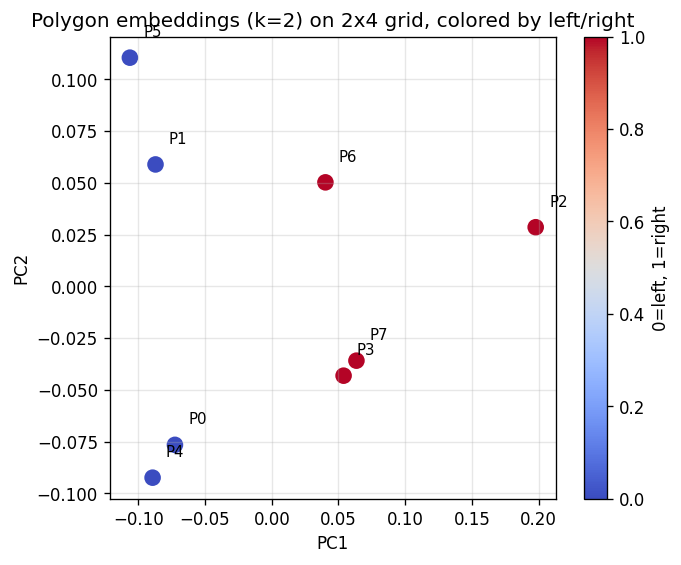

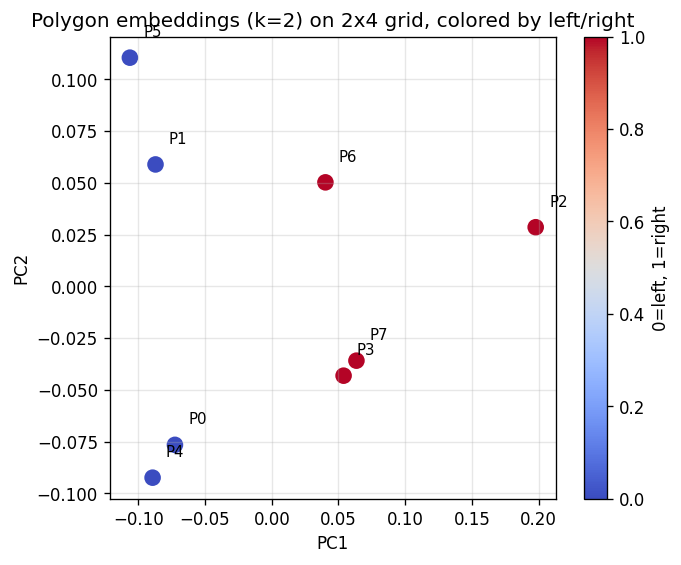

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, rand_score


y_poly_true = []
for i in range(2):    
    for j in range(4):  
        if j <= 1:
            y_poly_true.append(0)  
        else:
            y_poly_true.append(1)  
y_poly_true = np.array(y_poly_true)

print("True polygon labels (0=left, 1=right):", y_poly_true)

# PCA for visualization
pca_poly = PCA(n_components=2, random_state=0)
poly_2d = pca_poly.fit_transform(poly_emb)

# KMeans with k=2
kmeans_poly = KMeans(n_clusters=2, random_state=0)
poly_labels_pred = kmeans_poly.fit_predict(poly_emb)

poly_ari = adjusted_rand_score(y_poly_true, poly_labels_pred)
poly_ri = rand_score(y_poly_true, poly_labels_pred)

print(f"Polygon community test: ARI = {poly_ari:.3f}, RI = {poly_ri:.3f}")
print("True labels:   ", y_poly_true)
print("KMeans labels: ", poly_labels_pred)

plt.figure(figsize=(6,5))
plt.scatter(poly_2d[:, 0], poly_2d[:, 1], c=y_poly_true, s=80, cmap="coolwarm")
for i, (x, y) in enumerate(poly_2d):
    plt.text(x + 0.01, y + 0.01, f"P{i}", fontsize=9)
plt.title("Polygon embeddings (k=2) on 2x4 grid, colored by left/right")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="0=left, 1=right")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(poly_2d[:, 0], poly_2d[:, 1], c=poly_labels_pred, s=80, cmap="coolwarm")
for i, (x, y) in enumerate(poly_2d):
    plt.text(x + 0.01, y + 0.01, f"P{i}", fontsize=9)
plt.title("Polygon embeddings (k=2) on 2x4 grid, colored by left/right")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="0=left, 1=right")
plt.show()


In [ ]:
import networkx as nx
import numpy as np
from pytspl.cell_complex import CellComplex

# Parameters
m = 6  # size of each clique

# Clique A
# Clique B 
nodes_A = list(range(m))
nodes_B = list(range(m, 2*m))
nodes = nodes_A + nodes_B

G_edge = nx.Graph()
G_edge.add_nodes_from(nodes)
G_edge.add_edges_from([(u, v) for u in nodes_A for v in nodes_A if u < v])
G_edge.add_edges_from([(u, v) for u in nodes_B for v in nodes_B if u < v])

# Add m bridge edges 
bridge_edges = [(i, m + i) for i in range(m)]  
G_edge.add_edges_from(bridge_edges)

edges = list(G_edge.edges())

print("Nodes:", len(nodes))
print("Edges:", len(edges))
print("First 10 edges:", edges[:10])
print("Bridge edges:", bridge_edges)

# Build a CellComplex
cc_edges = CellComplex(
    nodes=nodes,
    edges=edges,
    polygons=[],         
    node_features={},
    edge_features={},
)

print("\nCellComplex for edge test:")
print("Nodes:", len(cc_edges.nodes))
print("Edges:", len(cc_edges.edges))
print("Polygons:", len(cc_edges.polygons))


Nodes: 12
Edges: 36
First 10 edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 2), (1, 3), (1, 4), (1, 5)]
Bridge edges: [(0, 6), (1, 7), (2, 8), (3, 9), (4, 10), (5, 11)]

CellComplex for edge test:
Nodes: 12
Edges: 36
Polygons: 0


In [21]:
from pytspl.embeddings.k_simplex2vec import cell2vec

emb_dim_edge = 16
walk_length_edge = 10
number_walks_edge = 40

edge_emb = cell2vec(
    cc=cc_edges,
    k=1,
    emb_dim=emb_dim_edge,
    walk_length=walk_length_edge,
    number_walks=number_walks_edge,
    scheme="uniform",
    laziness=None,
    seed=42,
)

print("Edge embedding shape:", edge_emb.shape)


Edge embedding shape: (36, 16)


Counts per edge class: Counter({0: 15, 1: 15, 2: 6})

Edge structural-role test: ARI = 1.000, RI = 1.000

Cluster -> true-class counts:
Cluster 0, size 6: Counter({2: 6})
Cluster 1, size 15: Counter({1: 15})
Cluster 2, size 15: Counter({0: 15})


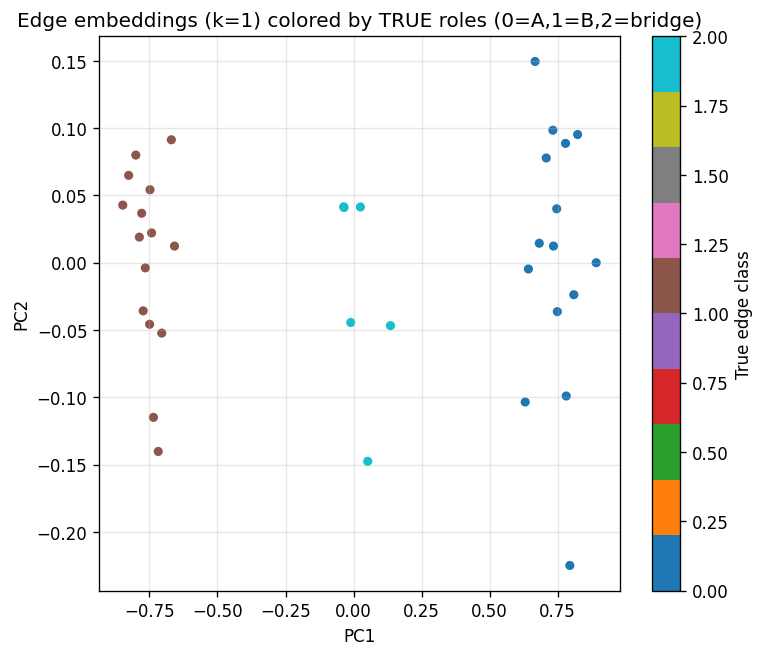

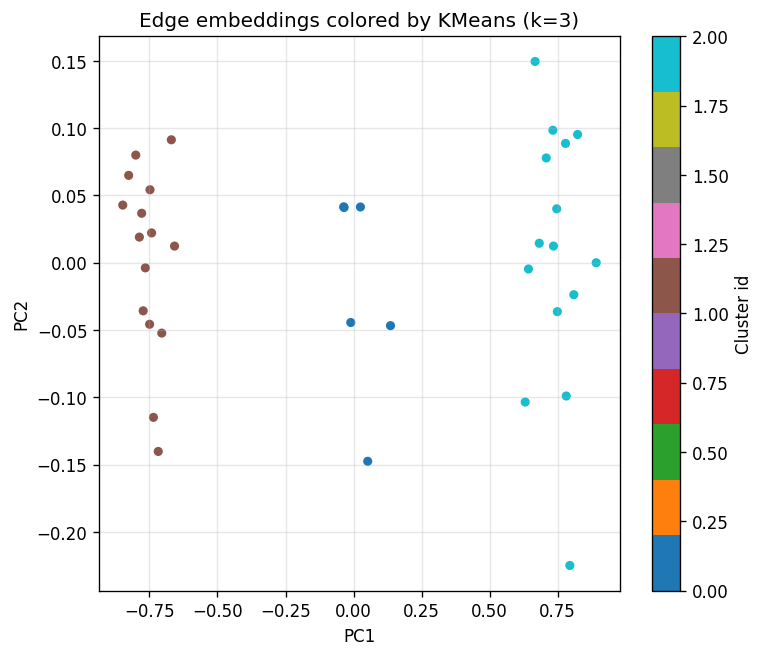

In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, rand_score
import matplotlib.pyplot as plt
from collections import Counter

edge_list = list(cc_edges.edges)

# Label edges:
#  0 = inside clique A
#  1 = inside clique B
#  2 = bridge (A-B)
y_edge_true = []
for (u, v) in edge_list:
    if u in nodes_A and v in nodes_A:
        y_edge_true.append(0)
    elif u in nodes_B and v in nodes_B:
        y_edge_true.append(1)
    else:
        y_edge_true.append(2)
y_edge_true = np.array(y_edge_true)

print("Counts per edge class:", Counter(y_edge_true))

# KMeans with k=3
kmeans_e = KMeans(n_clusters=3, random_state=0)
edge_labels_pred = kmeans_e.fit_predict(edge_emb)

ari_e = adjusted_rand_score(y_edge_true, edge_labels_pred)
ri_e = rand_score(y_edge_true, edge_labels_pred)
print(f"\nEdge structural-role test: ARI = {ari_e:.3f}, RI = {ri_e:.3f}")

# Check composition of each cluster
print("\nCluster -> true-class counts:")
for c in range(3):
    idx = np.where(edge_labels_pred == c)[0]
    print(f"Cluster {c}, size {len(idx)}:", Counter(y_edge_true[idx]))

# PCA for visualization
pca_e = PCA(n_components=2, random_state=0)
edge_2d = pca_e.fit_transform(edge_emb)

plt.figure(figsize=(7,6))
plt.scatter(edge_2d[:,0], edge_2d[:,1], c=y_edge_true, s=20, cmap="tab10")
plt.title("Edge embeddings (k=1) colored by TRUE roles (0=A,1=B,2=bridge)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="True edge class")
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(edge_2d[:,0], edge_2d[:,1], c=edge_labels_pred, s=20, cmap="tab10")
plt.title("Edge embeddings colored by KMeans (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="Cluster id")
plt.show()


In [ ]:
import networkx as nx
import numpy as np
from collections import Counter

from pytspl.cell_complex import CellComplex

# Parameters
n1 = 30         # size of block A
n2 = 30         # size of block B
p1 = 0.6        # dense internal prob in A
p2 = 0.2        # sparser internal prob in B
p_between = 0.05  # sparser between A and B

# Node indices
nodes_A = list(range(n1))              
nodes_B = list(range(n1, n1 + n2))       
nodes = nodes_A + nodes_B

G = nx.Graph()
G.add_nodes_from(nodes)

# edges inside A
for i in nodes_A:
    for j in nodes_A:
        if i < j and np.random.rand() < p1:
            G.add_edge(i, j)

# edges inside B
for i in nodes_B:
    for j in nodes_B:
        if i < j and np.random.rand() < p2:
            G.add_edge(i, j)

# edges between A and B
for i in nodes_A:
    for j in nodes_B:
        if np.random.rand() < p_between:
            G.add_edge(i, j)

edges = list(G.edges())

print("Nodes:", len(nodes))
print("Edges:", len(edges))
print("First 10 edges:", edges[:10])

cc_edges = CellComplex(
    nodes=nodes,
    edges=edges,
    polygons=[],    
    node_features={},
    edge_features={},
)

print("\nCellComplex for edge test:")
print("Nodes:", len(cc_edges.nodes))
print("Edges:", len(cc_edges.edges))
print("Polygons:", len(cc_edges.polygons))


Nodes: 60
Edges: 385
First 10 edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 7), (0, 9), (0, 10), (0, 11), (0, 14), (0, 15)]

CellComplex for edge test:
Nodes: 60
Edges: 385
Polygons: 0


In [ ]:
from pytspl.embeddings.k_simplex2vec import cell2vec

emb_dim = 32
walk_length = 15
number_walks = 40

edge_emb = cell2vec(
    cc=cc_edges,
    k=1,
    emb_dim=emb_dim,
    walk_length=walk_length,
    number_walks=number_walks,
    scheme="uniform",
    laziness=None,
    seed=42,
)

print("Edge embedding shape:", edge_emb.shape)


Edge embedding shape: (385, 32)


Counts per edge class: Counter({0: 258, 1: 82, 2: 45})

Edge role test (A/B/bridge): ARI = 0.707, RI = 0.854

Cluster -> true-class counts (0=A, 1=B, 2=bridge):
Cluster 0, size 88: Counter({1: 82, 2: 6})
Cluster 1, size 297: Counter({0: 258, 2: 39})
Cluster 2, size 0: Counter()


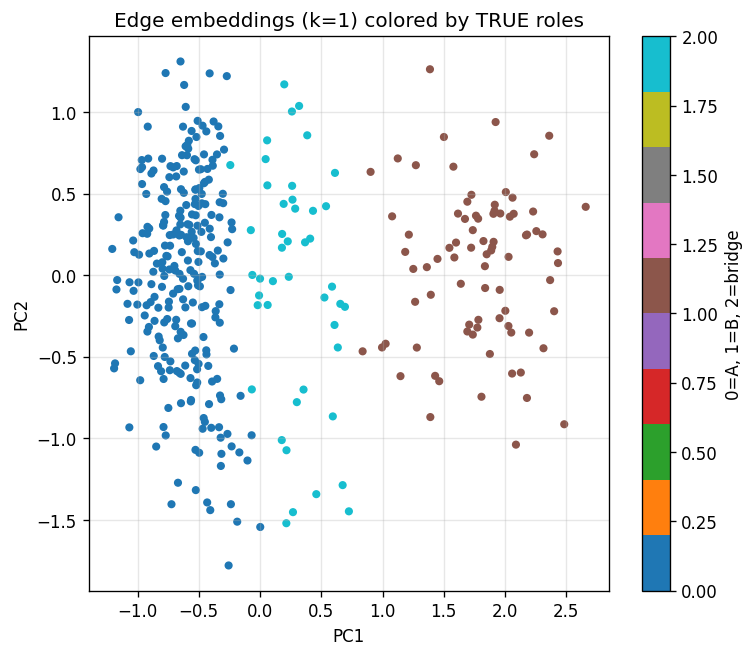

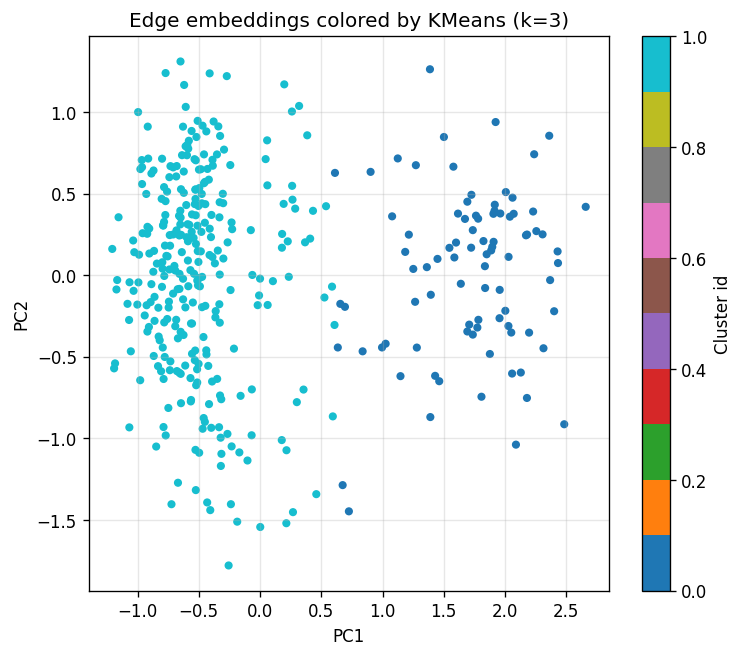

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, rand_score
import matplotlib.pyplot as plt

edge_list = list(cc_edges.edges)

# Structural labels:
#  0 = inside A (i,j both in nodes_A)
#  1 = inside B (i,j both in nodes_B)
#  2 = bridge between A and B
y_edge_true = []
for (u, v) in edge_list:
    if u in nodes_A and v in nodes_A:
        y_edge_true.append(0)
    elif u in nodes_B and v in nodes_B:
        y_edge_true.append(1)
    else:
        y_edge_true.append(2)
y_edge_true = np.array(y_edge_true)

print("Counts per edge class:", Counter(y_edge_true))

# KMeans with k=3
# kmeans_e = KMeans(n_clusters=, random_state=0)
edge_labels_pred = kmeans_e.fit_predict(edge_emb)

ari_e = adjusted_rand_score(y_edge_true, edge_labels_pred)
ri_e = rand_score(y_edge_true, edge_labels_pred)
print(f"\nEdge role test (A/B/bridge): ARI = {ari_e:.3f}, RI = {ri_e:.3f}")

print("\nCluster -> true-class counts (0=A, 1=B, 2=bridge):")
for c in range(3):
    idx = np.where(edge_labels_pred == c)[0]
    print(f"Cluster {c}, size {len(idx)}:", Counter(y_edge_true[idx]))

pca_e = PCA(n_components=2, random_state=0)
edge_2d = pca_e.fit_transform(edge_emb)

plt.figure(figsize=(7,6))
plt.scatter(edge_2d[:,0], edge_2d[:,1], c=y_edge_true, s=15, cmap="tab10")
plt.title("Edge embeddings (k=1) colored by TRUE roles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="0=A, 1=B, 2=bridge")
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(edge_2d[:,0], edge_2d[:,1], c=edge_labels_pred, s=15, cmap="tab10")
plt.title("Edge embeddings colored by KMeans (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.colorbar(label="Cluster id")
plt.show()
